# 🟢 Sphere Function — Algorithm Comparison

**Function:** $f(x) = \sum_{i=1}^{n} x_i^2$ &nbsp; | &nbsp; Global minimum: $f(0,...,0) = 0$

**Properties:** Continuous · Unimodal · Convex · Separable  
**Expected behaviour:** All algorithms should find the optimum. The interesting comparison is *how fast* and *how well they scale*.

**Algorithms tested:**
| Category | Algorithms |
|---|---|
| Classic | HC, SA |
| Evolution | GA, DE |
| Physics | GSA |
| Biology | PSO |
| Human | TLBO |

---
**Run order before this notebook:**
```bash
python experiments/dim2_experiment.py sphere
python experiments/convergence_experiment.py sphere
```

## §0 — Setup

In [1]:
import sys, warnings
sys.path.insert(0, '..')          # adjust if notebook lives in notebooks/
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import Image, display
from pathlib import Path

from problems.continuous import sphere
from utils.visualize import (
    load_pkl, load_summary_csv,
    plot_contour_2d,
    make_population_gif,
    make_trajectory_gif,
    plot_convergence,
    plot_best_vs_avg,
    plot_scalability_drop,
    plot_time_comparison,
    PALETTE,
)

mpl.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False})
plt.style.use('seaborn-v0_8-whitegrid')

RESULTS  = Path('../results')
GIFS_DIR = RESULTS / 'gifs' / 'sphere'
GIFS_DIR.mkdir(parents=True, exist_ok=True)

BOUNDS     = (-5.12, 5.12)
FUNC       = sphere
PROBLEM    = 'Sphere'

# Colour map: algo → colour (consistent across all plots)
ALGOS      = ['HC', 'SA', 'GA', 'DE', 'GSA', 'PSO', 'TLBO']
ALGO_COLOR = {a: PALETTE[i] for i, a in enumerate(ALGOS)}

print('Setup complete.')

Setup complete.


## §1 — Load Data

In [2]:
# 2D experiment results (population_history + trajectory)
dim2 = load_pkl(RESULTS / 'dim2_sphere.pkl')
print('dim2 algos:', list(dim2.keys()))

# Full convergence PKL (30D and 100D)
conv = load_pkl(RESULTS / 'convergence_sphere.pkl')
# conv structure: {algo: {dim: result_dict}}
print('conv algos:', list(conv.keys()))
print('dims available:', sorted({d for v in conv.values() for d in v.keys()}))

def flat(pkl, dim):
    """Flatten convergence PKL to {algo: result_dict} for a fixed dim."""
    return {algo: dim_data[dim]
            for algo, dim_data in pkl.items()
            if dim in dim_data}

conv_30  = flat(conv, 30)
conv_100 = flat(conv, 100)

dim2 algos: ['HC', 'PSO', 'SA', 'GA', 'DE', 'TLBO', 'GSA']
conv algos: ['HC', 'SA', 'GA', 'PSO', 'DE', 'TLBO', 'GSA']
dims available: [2, 30, 100]


---
## §2 — Case A: 2D Visualisation
### 2.1 — Landscape + Final Positions

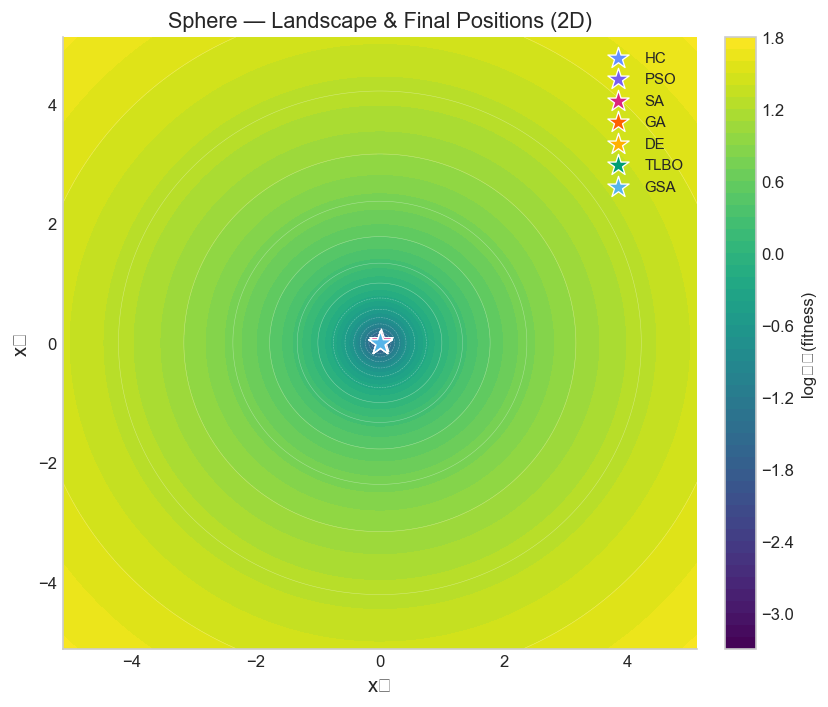

All algorithms should cluster near (0, 0) — the global minimum.


In [3]:
# Collect final best position of every algorithm
final_pos = {
    algo: data['best_solution'][:2]
    for algo, data in dim2.items()
}

fig, ax = plt.subplots(figsize=(7, 6))
plot_contour_2d(
    FUNC, BOUNDS,
    final_positions=final_pos,
    log_scale=True,
    title='Sphere — Landscape & Final Positions (2D)',
    ax=ax,
)
plt.tight_layout()
plt.savefig(RESULTS / 'sphere_contour_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print('All algorithms should cluster near (0, 0) — the global minimum.')

### 2.2 — Population / Trajectory GIFs
**HC and SA:** single-agent trajectory GIF (path of best solution over time)  
**GA, DE, GSA, PSO, TLBO:** full population movement GIF

In [4]:
# ── HC trajectory GIF ────────────────────────────────────────────────────────
hc_traj = dim2['HC']['trajectory']   # shape (T, 2)
gif_hc  = GIFS_DIR / 'HC_trajectory.gif'
make_trajectory_gif(
    FUNC, BOUNDS, hc_traj, 'HC',
    gif_hc, n_frames=60, fps=10, log_scale=True,
)
display(Image(filename=gif_hc))

[make_trajectory_gif] WARNING: trajectory for 'HC' is invalid (shape=()). Re-run dim2_experiment.py to regenerate PKL.


FileNotFoundError: [Errno 2] No such file or directory: '..\\results\\gifs\\sphere\\HC_trajectory.gif'

In [ ]:
# ── SA trajectory GIF ────────────────────────────────────────────────────────
sa_traj = dim2['SA']['trajectory']
gif_sa  = GIFS_DIR / 'SA_trajectory.gif'
make_trajectory_gif(
    FUNC, BOUNDS, sa_traj, 'SA',
    gif_sa, n_frames=60, fps=10, log_scale=True,
)
display(Image(filename=gif_sa))

In [ ]:
# ── Population GIFs for all population-based algorithms ──────────────────────
POP_ALGOS = ['GA', 'DE', 'GSA', 'PSO', 'TLBO']

for algo in POP_ALGOS:
    if algo not in dim2:
        print(f'{algo}: not in dim2 data, skipping.')
        continue
    gif_path = GIFS_DIR / f'{algo}_population.gif'
    make_population_gif(
        FUNC, BOUNDS,
        dim2[algo]['population_history'],
        algo,
        gif_path,
        best_history=dim2[algo]['trajectory'],
        n_frames=60, fps=10, log_scale=True,
    )
    print(f'\n{algo}:')
    display(Image(filename=gif_path))

---
## §3 — Case B & C: 30D vs 100D Analysis
### 3.1 — Convergence Curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

plot_convergence(
    conv_30, problem=PROBLEM, log_scale=True, smooth_window=5,
    title='Sphere — Convergence (30D)', ax=axes[0],
)
plot_convergence(
    conv_100, problem=PROBLEM, log_scale=True, smooth_window=5,
    title='Sphere — Convergence (100D)', ax=axes[1],
)

plt.suptitle('Convergence Speed Comparison: 30D vs 100D', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / 'sphere_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 — Best Fitness & Execution Time (30D vs 100D)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Best vs average quality at 30D
plot_best_vs_avg(
    conv_30, problem=PROBLEM, dim=30,
    log_scale=True, ax=axes[0],
)
# Best vs average quality at 100D
plot_best_vs_avg(
    conv_100, problem=PROBLEM, dim=100,
    log_scale=True, ax=axes[1],
)

plt.suptitle('Solution Quality: 30D vs 100D', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / 'sphere_quality.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Build summary DataFrame for time comparison
rows = []
for algo, dim_data in conv.items():
    for dim, res in dim_data.items():
        rows.append({
            'algorithm': algo,
            'dimensions': dim,
            'mean_fitness': res['best_fitness'],
            'mean_time':    res['execution_time_seconds'],
        })
summary_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_time_comparison(summary_df[summary_df['dimensions'] == 30],
                     dim=30, problem=PROBLEM, ax=axes[0])
plot_time_comparison(summary_df[summary_df['dimensions'] == 100],
                     dim=100, problem=PROBLEM, ax=axes[1])
plt.suptitle('Execution Time: 30D vs 100D', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / 'sphere_time.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 — Scalability: Performance Drop 30D → 100D

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_scalability_drop(
    conv_30, conv_100,
    dim_low=30, dim_high=100,
    problem=PROBLEM, log_scale=True, ax=ax,
)
plt.tight_layout()
plt.savefig(RESULTS / 'sphere_scalability_drop.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 — Scalability Table

In [ ]:
# Compute % performance drop and time increase per algorithm
table_rows = []
for algo in ALGOS:
    if algo not in conv_30 or algo not in conv_100:
        continue
    bf_30  = conv_30[algo]['best_fitness']
    bf_100 = conv_100[algo]['best_fitness']
    t_30   = conv_30[algo]['execution_time_seconds']
    t_100  = conv_100[algo]['execution_time_seconds']

    fit_drop = (bf_100 - bf_30) / max(abs(bf_30), 1e-12) * 100
    time_inc = (t_100  - t_30)  / max(t_30, 1e-12) * 100

    table_rows.append({
        'Algorithm'       : algo,
        'BestFit@30D'     : f'{bf_30:.3e}',
        'BestFit@100D'    : f'{bf_100:.3e}',
        'FitnessDrop%'    : f'{fit_drop:+.1f}%',
        'Time@30D(s)'     : f'{t_30:.2f}',
        'Time@100D(s)'    : f'{t_100:.2f}',
        'TimeIncrease%'   : f'{time_inc:+.1f}%',
    })

scale_df = pd.DataFrame(table_rows)
# Sort by raw fitness drop (worst degradation last)
scale_df = scale_df.sort_values(
    'FitnessDrop%',
    key=lambda s: s.str.replace('%','').str.replace('+','').astype(float)
)

print('Scalability Table — Sphere (30D → 100D)\n')
print(scale_df.to_string(index=False))
scale_df.to_csv(RESULTS / 'sphere_scalability_table.csv', index=False)

---
## §4 — Summary Observations

Fill in after running:

| Observation | Expected | Actual |
|---|---|---|
| Fastest convergence (30D) | DE / PSO | — |
| Least scalability degradation | PSO / TLBO | — |
| Biggest time increase 30→100D | GSA (O(N²)) | — |
| HC behaviour | Restarts visible in GIF | — |